### 1. Tải bộ dữ liệu:

In [10]:
# !gdown --id 1GaTMURqIQTjtalbNVAyVgPIEis21A0r8

In [11]:
# !unzip -q 'FER-2013.zip'

### 2. Import các thư viện cần thiết:

In [12]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Resize
from torchvision.io import read_image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### 3. Cài đặt giá trị ngẫu nhiên cố định và thiết bị tính toán:

In [13]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
random_state = 59
np.random.seed(random_state)
torch.manual_seed(random_state)
if torch.cuda.is_available():
	torch.cuda.manual_seed(random_state)

### 4. Đọc số lượng class trong dataset:

In [14]:
train_dir = 'FER-2013/train'
test_dir = 'FER-2013/test'

classes = os.listdir(train_dir)

label2idx = {cls: idx for idx, cls in enumerate(classes)}
idx2label = {idx: cls for cls, idx in label2idx.items()}

### 5. Xây dựng DataLoader:

In [15]:
test_img_path = 'FER-2013/train/angry/Training_10118481.jpg'
img = cv2.imread(test_img_path)
img_height, img_width = (128, 128)
print(f'Image height : {img_height}')
print(f'Image width : {img_width}')

Image height : 128
Image width : 128


In [16]:
class ImageDataset(Dataset):
	def __init__(self, img_dir, norm, label2idx,
	             split = 'train', train_ratio = 0.8):
		self.resize = Resize((img_height, img_width))
		self.norm = norm
		self.split = split
		self.train_ratio = train_ratio
		self.img_dir = img_dir
		self.label2idx = label2idx
		self.img_paths, self.img_labels = self.read_img_files()

		if split in ['train', 'val'] and 'train' in img_dir.lower():
			train_data, val_data = train_test_split(
				list(zip(self.img_paths, self.img_labels)),
				train_size = train_ratio,
				random_state = random_state,
				stratify = self.img_labels
			)

		if split == 'train':
			self.img_paths, self.img_labels = zip(*train_data)
		elif split == 'val':
			self.img_paths, self.img_labels = zip(*val_data)

	def read_img_files(self):
		img_paths = []
		img_labels = []
		for cls in self.label2idx.keys():
			for img in os.listdir(os.path.join(self.img_dir, cls)):
				img_paths.append(os.path.join(self.img_dir, cls, img)
				                 )
				img_labels.append(cls)

		return img_paths, img_labels

	def __len__(self):
		return len(self.img_paths)

	def __getitem__(self, idx):
		img_path = self.img_paths[idx]
		cls = self.img_labels[idx]
		img = self.resize(read_image(img_path))
		img = img.type(torch.float32)
		label = self.label2idx[cls]
		if self.norm:
			img = (img / 127.5) - 1
		return img, label



In [17]:
batch_size = 256

train_dataset = ImageDataset(train_dir, True,
                             label2idx, split = 'train')
train_loader = DataLoader(train_dataset,
                          batch_size = batch_size,
                          shuffle = True)

val_dataset = ImageDataset(train_dir, True,
                           label2idx, split = 'val')
val_loader = DataLoader(val_dataset,
                        batch_size = batch_size,
                        shuffle = False)

test_dataset = ImageDataset(test_dir, True,
                            label2idx, split = 'test')
test_loader = DataLoader(test_dataset,
                         batch_size = batch_size,
                         shuffle = False)

(-0.5, 127.5, 127.5, -0.5)

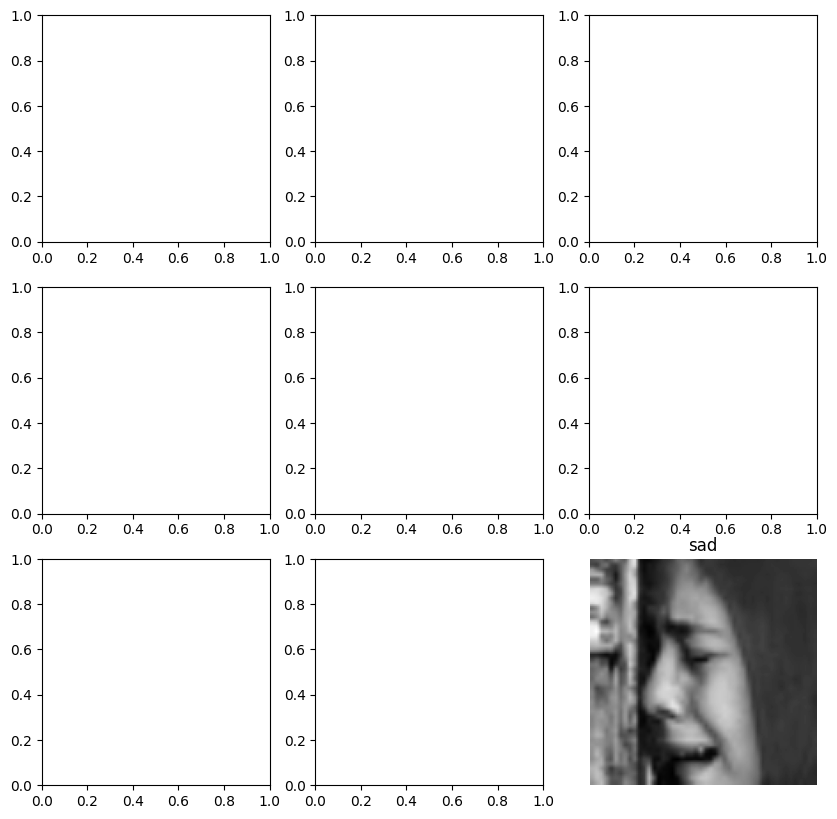

In [19]:
image_batch, label_batch = next(iter(train_loader))

plt.figure(figsize = (10, 10))
for i in range(9):
	ax = plt.subplot(3, 3, i + 1)
minv = image_batch[i].numpy().min()
maxv = image_batch[i].numpy().max()
plt.imshow(np.squeeze(image_batch[i].numpy()), vmin = minv, vmax = maxv
           , cmap = "gray")
label = label_batch[i]
plt.title(idx2label[label.item()])
plt.axis("off")

### 6. Xây dựng mạng MLP:

In [20]:
class MLP(nn.Module):
	def __init__(self, input_dims, hidden_dims, output_dims):
		super(MLP, self).__init__()
		self.linear1 = nn.Linear(input_dims, hidden_dims * 4)
		self.linear2 = nn.Linear(hidden_dims * 4, hidden_dims * 2)
		self.linear3 = nn.Linear(hidden_dims * 2, hidden_dims)
		self.output = nn.Linear(hidden_dims, output_dims)

	def forward(self, x):
		x = nn.Flatten()(x)
		x = self.linear1(x)
		x = F.relu(x)
		x = self.linear2(x)
		x = F.relu(x)
		x = self.linear3(x)
		x = F.relu(x)
		out = self.output(x)
		return out.squeeze(1)


input_dims = img_height * img_width
output_dims = len(classes)
hidden_dims = 64
lr = 1e-2

model = MLP(input_dims = input_dims,
            hidden_dims = hidden_dims,
            output_dims = output_dims).to(device)

### 7. Khai báo hàm loss và optimizer:

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = lr)

### 8. Xây dựng hàm tính độ chính xác:

In [22]:
def compute_accuracy(y_hat, y_true):
	_, y_hat = torch.max(y_hat, dim = 1)
	correct = (y_hat == y_true).sum().item()
	accuracy = correct / len(y_true)
	return accuracy

### 9. Huấn luyện mô hình:

In [23]:
epochs = 40
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
	train_loss = 0.0
	train_target = []
	train_predict = []
	model.train()
	for X_samples, y_samples in train_loader:
		X_samples = X_samples.to(device)
		y_samples = y_samples.to(device)
		optimizer.zero_grad()
		outputs = model(X_samples)

		loss = criterion(outputs, y_samples)
		loss.backward()
		optimizer.step()
		train_loss += loss.item()

		train_predict.append(outputs.detach().cpu())
		train_target.append(y_samples.cpu())

	train_loss /= len(train_loader)
	train_losses.append(train_loss)

	train_predict = torch.cat(train_predict)
	train_target = torch.cat(train_target)
	train_acc = compute_accuracy(train_predict, train_target)
	train_accs.append(train_acc)

	val_loss = 0.0
	val_target = []
	val_predict = []
	model.eval()
	with torch.no_grad():
		for X_samples, y_samples in val_loader:
			X_samples = X_samples.to(device)
			y_samples = y_samples.to(device)
			outputs = model(X_samples)
			val_loss += criterion(outputs, y_samples).item()

			val_predict.append(outputs.cpu())
			val_target.append(y_samples.cpu())

		val_loss /= len(val_loader)
		val_losses.append(val_loss)

		val_predict = torch.cat(val_predict)
		val_target = torch.cat(val_target)
		val_acc = compute_accuracy(val_predict, val_target)
		val_accs.append(val_acc)

		print(f'\nEPOCH {epoch + 1}:\tTraining loss : {train_loss :.3f}\tValidation loss : {val_loss :.3f}')


EPOCH 1:	Training loss : 1.912	Validation loss : 1.888

EPOCH 2:	Training loss : 1.865	Validation loss : 1.845

EPOCH 3:	Training loss : 1.826	Validation loss : 1.813

EPOCH 4:	Training loss : 1.799	Validation loss : 1.792

EPOCH 5:	Training loss : 1.780	Validation loss : 1.776

EPOCH 6:	Training loss : 1.762	Validation loss : 1.758

EPOCH 7:	Training loss : 1.744	Validation loss : 1.738

EPOCH 8:	Training loss : 1.722	Validation loss : 1.715

EPOCH 9:	Training loss : 1.699	Validation loss : 1.694

EPOCH 10:	Training loss : 1.677	Validation loss : 1.677

EPOCH 11:	Training loss : 1.660	Validation loss : 1.663

EPOCH 12:	Training loss : 1.646	Validation loss : 1.654

EPOCH 13:	Training loss : 1.634	Validation loss : 1.643

EPOCH 14:	Training loss : 1.625	Validation loss : 1.635

EPOCH 15:	Training loss : 1.614	Validation loss : 1.629

EPOCH 16:	Training loss : 1.606	Validation loss : 1.623

EPOCH 17:	Training loss : 1.597	Validation loss : 1.617

EPOCH 18:	Training loss : 1.589	Validat

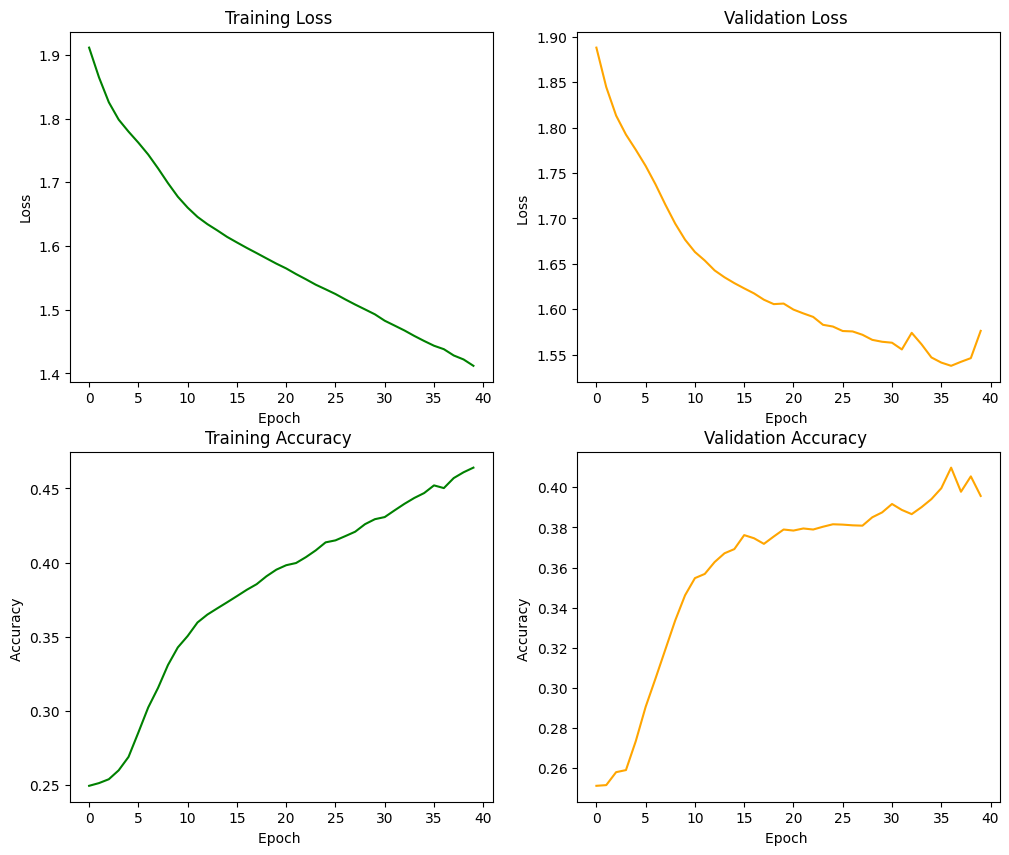

In [24]:
fig, ax = plt.subplots(2, 2, figsize = (12, 10))
ax[0, 0].plot(train_losses, color = 'green')
ax[0, 0].set(xlabel = 'Epoch ', ylabel = 'Loss')
ax[0, 0].set_title('Training Loss ')

ax[0, 1].plot(val_losses, color = 'orange')
ax[0, 1].set(xlabel = 'Epoch ', ylabel = 'Loss ')
ax[0, 1].set_title('Validation Loss ')

ax[1, 0].plot(train_accs, color = 'green')
ax[1, 0].set(xlabel = 'Epoch ', ylabel = 'Accuracy ')
ax[1, 0].set_title('Training Accuracy ')
ax[1, 1].plot(val_accs, color = 'orange')
ax[1, 1].set(xlabel = 'Epoch ', ylabel = 'Accuracy ')
ax[1, 1].set_title('Validation Accuracy ')

plt.show()

### 10. Đánh giá mô hình:

In [25]:
test_target = []
test_predict = []
model.eval()
with torch.no_grad():
	for X_samples, y_samples in test_loader:
		X_samples = X_samples.to(device)
		y_samples = y_samples.to(device)
		outputs = model(X_samples)

		test_predict.append(outputs.cpu())
		test_target.append(y_samples.cpu())

	test_predict = torch.cat(test_predict)
	test_target = torch.cat(test_target)
	val_acc = compute_accuracy(test_predict, test_target)

	print('Evaluation on test set :')
	print(f'Accuracy : {val_acc}')

Evaluation on test set :
Accuracy : 0.3966285873502368
